# KAN-Assisted Quantum Detector Tomography — Three-Way Comparison

**Goal.** Reconstruct the 1-click POVM element $\hat\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).

| Method | What it produces | How we score it |
|---|---|---|
| **KAN** | a probability surface $p_1(\lvert\alpha\rvert^2,\theta)$ (no matrix, no physics) | test RMS directly |
| **Joint SDP** | the matrix $\hat\Pi_1$, all bands at once | Born-rule predict → test RMS |
| **Recursive SDP** | the matrix $\hat\Pi_1$, one diagonal band at a time (paper's algorithm) | Born-rule predict → test RMS |

**Key idea you asked about:** the SDPs produce the **matrix**; the KAN only predicts the **click probability**. The one thing all three share is a click-probability prediction on the same test rows — that's the level playing field (RMS). The SDPs *additionally* give a matrix we can inspect for physics.

Data: `41566_2012_BFnphoton2012107_MOESM4_ESM.xls` (APD-regime weak-homodyne detector).

## 0 · Setup
Run once. CPU-only; no GPU needed.

In [2]:
# !pip install pykan torch cvxpy xlrd scipy scikit-learn matplotlib nbformat
import numpy as np, matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy.linalg import sqrtm
from sklearn.model_selection import train_test_split
import cvxpy as cp
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz   # np.trapz renamed in NumPy 2.0
np.random.seed(0)

In [3]:
DATA_FILE = "data/41566_2012_BFnphoton2012107_MOESM4_ESM.xls"   # <-- point to your .xls

## 1 · Load the data

Columns: $\lvert\alpha\rvert^2$ (brightness), $\theta$ (phase), #0-click, #1-click.
Input $X=(\lvert\alpha\rvert^2,\theta)$; label $y=p_1=\dfrac{\#1\text{-click}}{\#0\text{-click}+\#1\text{-click}}$.

In [4]:
import xlrd
sh = xlrd.open_workbook(DATA_FILE).sheet_by_index(0)
rows = np.array([sh.row_values(r) for r in range(1, sh.nrows)])
a2, theta, c0, c1 = rows[:,0], rows[:,1], rows[:,2], rows[:,3]
X = np.column_stack([a2, theta])
y = c1 / (c0 + c1)
print("rows: %d | |a|^2 %.3f..%.1f | theta %.2f..%.2f | p1 %.3f..%.3f"
      % (len(X), a2.min(), a2.max(), theta.min(), theta.max(), y.min(), y.max()))

rows: 3720 | |a|^2 0.178..38.5 | theta 0.01..6.28 | p1 0.001..0.997


## 2 · Train/test split — 80/20

**One split, fixed seed, shared by all three methods** so the comparison is apples-to-apples.
The SDPs reconstruct from the FULL data (that's how the paper does it — a POVM needs all
brightness/phase coverage to be well-conditioned) but are *scored* on the same held-out `Xte`.
The KAN is *trained* only on `Xtr` and scored on `Xte`.

In [5]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=42)
print("train:", len(Xtr), " test:", len(Xte))

train: 2976  test: 744


## 3 · Look at what every method must reproduce

Left: the click probability over the whole (brightness, phase) plane.
Right: phase dependence at a few fixed brightnesses — the *wiggle* with phase IS the wave
(coherence) signal the off-diagonals encode. Flat = no phase sensitivity; wavy = phase-sensitive.

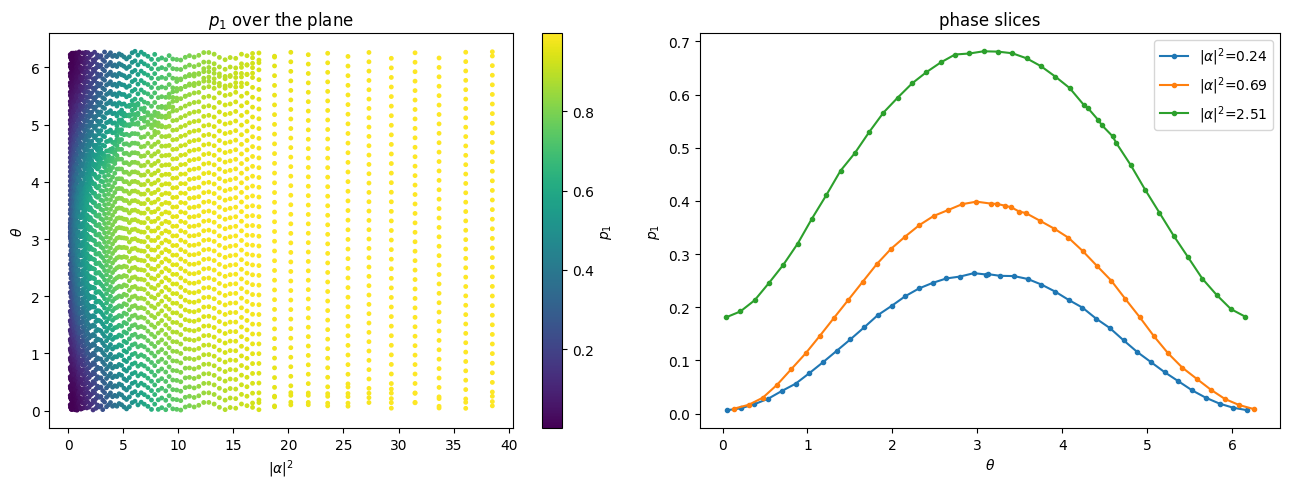

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))
sc = ax[0].scatter(X[:,0], X[:,1], c=y, s=6, cmap="viridis")
ax[0].set_xlabel(r"$|\alpha|^2$"); ax[0].set_ylabel(r"$\theta$"); ax[0].set_title(r"$p_1$ over the plane")
plt.colorbar(sc, ax=ax[0], label=r"$p_1$")
for k in np.unique(np.round(a2,4))[[3,15,35]]:
    m = np.round(a2,4)==k
    o = np.argsort(X[m,1])
    ax[1].plot(X[m,1][o], y[m][o], "-o", ms=3, label=r"$|\alpha|^2$=%.2f"%k)
ax[1].set_xlabel(r"$\theta$"); ax[1].set_ylabel(r"$p_1$"); ax[1].set_title("phase slices"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Shared constants & helpers

- `D` truncation (Hilbert-space cutoff). Data reaches $\lvert\alpha\rvert^2\approx38$, so $D=58$ holds
  the coherent states with negligible leakage.
- `L` = number of leading off-diagonal bands (paper: higher bands negligible, $l\ll d$).
- `GAMMA` = regulariser (paper uses 0.5).
- `born_predict` runs the Born rule **forward**: matrix → click probabilities (this is how we
  score an SDP matrix on the test set).
- `rms` = our common yardstick.

In [7]:
D, L, GAMMA = 58, 4, 0.5
logfac = gammaln(np.arange(D + 5) + 1)

def born_predict(Pi1, Xq):
    """Forward Born rule: given POVM matrix Pi1, predict p1 for each (|a|^2, theta) row."""
    n = np.arange(D); pred = np.empty(len(Xq))
    for i, (aa, pp) in enumerate(Xq):
        ab = np.sqrt(aa)
        c = np.exp(-0.5*ab**2 + n*np.log(ab+1e-300) - 0.5*logfac[:D]) * np.exp(1j*n*pp)
        pred[i] = np.real(c.conj() @ Pi1 @ c)
    return pred

def rms(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))

# leakage check: does D=58 contain the brightest coherent states?
def leakage(mag):
    n = np.arange(D); a2v = mag*mag
    return 1 - np.exp(-a2v + n*np.log(a2v+1e-300) - gammaln(n+1)).sum()
print("D=%d  max leakage over data: %.2e" % (D, max(leakage(np.sqrt(k)) for k in np.unique(np.round(a2,4)))))

D=58  max leakage over data: 2.04e-03


---
# Method 1 · KAN — learn the click probability directly

The KAN learns $p_1(\lvert\alpha\rvert^2,\theta)$ as a plain function of two inputs. **No matrix, no
Born rule, no positivity** — it just fits the surface. Trained on `Xtr` only, scored on `Xte`.

**Design choices**
- Inputs: `log1p(|a|^2)` (compresses the wide brightness range) and raw $\theta$, each normalised to
  $[-1,1]$ using **train statistics only** (no test leakage).
- Architecture `[2,3,1]` — 2 inputs → 3 hidden → 1 output. A single hidden node can't represent the
  bright-end saturation; 3 is enough without overfitting.
- `grid=5, k=3` cubic splines to start; we refine the grid for accuracy.

In [8]:
from kan import KAN
import torch

# --- inputs: log1p brightness + phase, normalised with TRAIN stats only ---
def featurize(Xraw, stats=None):
    f = np.column_stack([np.log1p(Xraw[:,0]), Xraw[:,1]])
    if stats is None:
        lo, hi = f.min(0), f.max(0)
        stats = (lo, hi)
    lo, hi = stats
    fn = 2*(f - lo)/(hi - lo) - 1     # -> [-1, 1]
    return fn, stats

Ftr, stats = featurize(Xtr)
Fte, _     = featurize(Xte, stats)

# pykan creates its parameters in float32, so the dataset must be float32 too --
# float64 here triggers "expected m1 and m2 to have the same dtype" in the spline einsum.
dataset = {
    "train_input":  torch.tensor(Ftr, dtype=torch.float32),
    "train_label":  torch.tensor(ytr.reshape(-1,1), dtype=torch.float32),
    "test_input":   torch.tensor(Fte, dtype=torch.float32),
    "test_label":   torch.tensor(yte.reshape(-1,1), dtype=torch.float32),
}
print("KAN inputs ready:", Ftr.shape, "->", ytr.shape)

KAN inputs ready: (2976, 2) -> (2976,)


### 1.1 · Baseline fit + grid refinement
Train at grid=5, then refine 5→10→20. Refinement is the main accuracy lever for a KAN.

In [9]:
model = KAN(width=[2,3,1], grid=5, k=3, seed=0)
model.fit(dataset, opt="LBFGS", steps=60)

for g in [10, 20]:
    model = model.refine(g)
    model.fit(dataset, opt="LBFGS", steps=40)

with torch.no_grad():
    p_te_kan = model(dataset["test_input"]).numpy().ravel()
p_te_kan = np.clip(p_te_kan, 0, 1)      # clip into valid probability range
rms_kan = rms(p_te_kan, yte)
print("KAN  test RMS : %.5f" % rms_kan)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.10e-03 | test_loss: 3.31e-03 | reg: 8.02e+00 | : 100%|█| 60/60 [00:04<00:00, 12.15it


saving model version 0.1
saving model version 0.2


| train_loss: 2.99e-03 | test_loss: 3.27e-03 | reg: 8.07e+00 | : 100%|█| 40/40 [00:03<00:00, 11.46it


saving model version 0.3
saving model version 0.4


| train_loss: 2.86e-03 | test_loss: 3.20e-03 | reg: 8.13e+00 | : 100%|█| 40/40 [00:03<00:00, 10.88it

saving model version 0.5
KAN  test RMS : 0.00320


### 1.2 · Fit quality
Left: predicted vs true (points should hug the diagonal). Right: a phase slice, KAN vs measured.

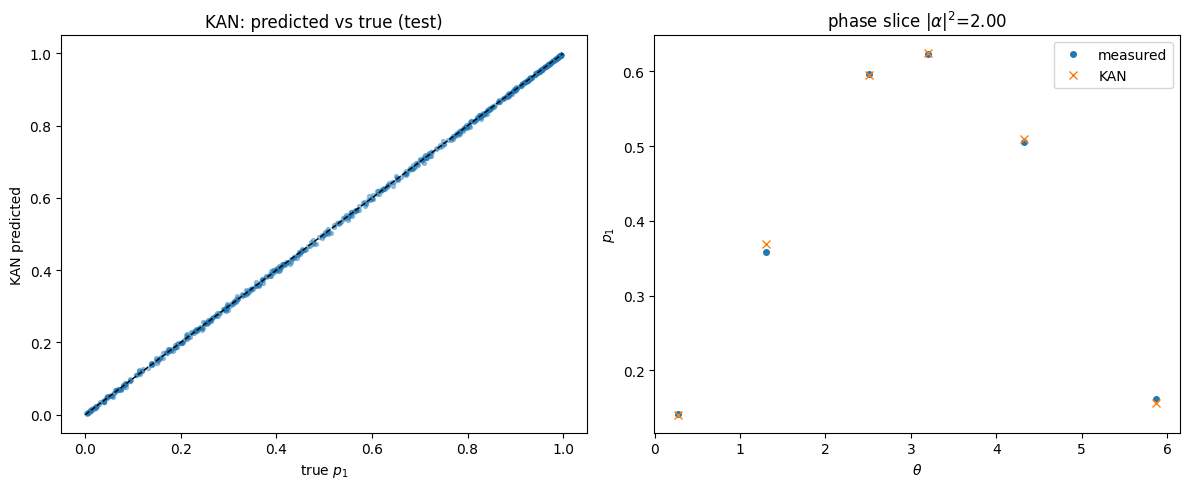

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(yte, p_te_kan, s=8, alpha=.4)
ax[0].plot([0,1],[0,1],"k--",lw=1)
ax[0].set_xlabel("true $p_1$"); ax[0].set_ylabel("KAN predicted"); ax[0].set_title("KAN: predicted vs true (test)")

k = np.unique(np.round(Xte[:,0],4))[len(np.unique(np.round(Xte[:,0],4)))//3]
m = np.round(Xte[:,0],4)==k; o = np.argsort(Xte[m,1])
ax[1].plot(Xte[m,1][o], yte[m][o], "o", ms=4, label="measured")
ax[1].plot(Xte[m,1][o], p_te_kan[m][o], "x", ms=6, label="KAN")
ax[1].set_xlabel(r"$\theta$"); ax[1].set_ylabel(r"$p_1$"); ax[1].set_title(r"phase slice $|\alpha|^2$=%.2f"%k); ax[1].legend()
plt.tight_layout(); plt.show()

---
# Method 2 · Joint SDP — reconstruct the whole matrix at once

One Hermitian PSD variable $\hat\Pi_1$, **all bands $l=0\ldots L$ solved simultaneously** against the
full 2-D statistics, subject to $0\preceq\hat\Pi_1\preceq I$ (positivity + completeness).

- **Pro:** uses every data point under one constraint → most accurate here.
- **Con:** variable count grows like $d^2$; intractable for the paper's $d=450$ detector.

This is our accurate **reference**.

In [11]:
ab, ph = np.sqrt(X[:,0]), X[:,1]
idx = [(j,k) for j in range(D) for k in range(j, min(j+L+1, D))]   # upper bands only
Are = np.zeros((len(X), len(idx))); Aim = np.zeros((len(X), len(idx)))
for c,(j,k) in enumerate(idx):
    C = np.exp(-ab**2 + (j+k)*np.log(ab+1e-300) - 0.5*(logfac[j]+logfac[k])) * np.exp(1j*(k-j)*ph)
    if j==k: Are[:,c] = C.real
    else:    Are[:,c] = 2*C.real; Aim[:,c] = -2*C.imag

Pij = cp.Variable((D,D), hermitian=True); ii = tuple(np.array(idx).T)
pred = Are @ cp.real(Pij[ii]) + Aim @ cp.imag(Pij[ii])
reg  = sum(cp.square(cp.abs(Pij[j,j+l] - Pij[j+1,j+1+l]))
           for l in range(L+1) for j in range(D-l-1))
cp.Problem(cp.Minimize(cp.sum_squares(pred - y) + GAMMA*reg),
           [Pij >> 0, np.eye(D) - Pij >> 0]).solve(solver=cp.SCS, max_iters=5000, eps=1e-5)

Pi_joint = (Pij.value + Pij.value.conj().T) / 2
rms_joint = rms(born_predict(Pi_joint, Xte), yte)
ev = np.linalg.eigvalsh(Pi_joint)
print("JOINT  test RMS %.5f | eig [%.4f, %.4f] | valid POVM: %s"
      % (rms_joint, ev.min(), ev.max(), ev.min() > -1e-3 and ev.max() < 1+1e-3))

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1565617274.py:14: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  [Pij >> 0, np.eye(D) - Pij >> 0]).solve(solver=cp.SCS, max_iters=5000, eps=1e-5)


JOINT  test RMS 0.00320 | eig [0.0007, 1.0000] | valid POVM: True


/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: divide by zero encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: overflow encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: invalid value encountered in matmul
  return values[0] @ values[1]
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: divide by zero encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: overflow encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)
/var/folders/01/wngn39

---
# Method 3 · Recursive SDP — the paper's literal algorithm

Peel the matrix apart **one diagonal band at a time** using the transformed-Husimi reduced
functions (SI Eq. 1). This is what drops the cost from $O(d^2)$ to $O(d)$ per band and makes the
$d=450$ detector tractable.

### 3.1 · Reduced functions $P^{(l)}$ — phase-average to isolate band $l$

$$P^{(l)}(\lvert\alpha\rvert)=\frac{1}{2\pi}\int_0^{2\pi} p_1(\alpha)\,e^{-il\theta}\,d\theta
   = e^{-|\alpha|^2}\sum_j (\Pi_1)_{j,j+l}\frac{|\alpha|^{2j+l}}{\sqrt{(j+l)!\,j!}}$$

**IMPORTANT — this is the part that bit us.** Eq. 1 is a *continuous integral* over a full phase
circle. The MOESM4 phases per brightness span ≈ $[0.03, 6.22]$, NOT a clean grid anchored at 0.
A plain `np.mean` over those points is a biased estimate of the integral and leaks a constant
imaginary artifact (~0.05) into every band — which swamps the tiny high-$l$ bands and inflated the
recursive RMS to ~0.078. We instead evaluate the integral honestly with the **trapezoidal rule**
over the actual sorted phases (wrapping the circle closed). That drops the artifact to ~0.003 and
the RMS into the paper's region.

In [12]:
keys = np.round(X[:,0], 4); uniq = np.unique(keys)

def reduced_P(l):
    """SI Eq. 1 via trapezoidal phase-integration (grid-offset robust)."""
    mags = np.array([np.sqrt(k) for k in uniq]); vals = []
    for k in uniq:
        m  = keys == k
        pph = X[m,1] % (2*np.pi); yy = y[m]
        o = np.argsort(pph); pph, yy = pph[o], yy[o]
        pe = np.concatenate([pph, [pph[0] + 2*np.pi]])         # close the loop
        f  = yy * np.exp(-1j*l*pph); fe = np.concatenate([f, [f[0]]])
        vals.append(trapz(fe, pe) / (2*np.pi))
    return mags, np.array(vals)

def F_matrix(mags, l):
    """Design matrix F[i,j] = e^{-|a|^2} |a|^{2j+l} / sqrt((j+l)! j!). Log-stabilised."""
    mags = np.asarray(mags, float); a2v = mags**2; n = D - l
    F = np.zeros((len(mags), n)); nz = mags > 0
    lm = np.zeros_like(mags); lm[nz] = np.log(mags[nz])
    for j in range(n):
        F[:, j] = np.where(nz, np.exp(np.clip(-a2v + (2*j+l)*lm - 0.5*(logfac[j+l]+logfac[j]), -700, 700)), 0.0)
    return F

# sanity: imag part of each band should now be ~0
m0, P0 = reduced_P(0)
# NOTE: the ratio may look large for high l -- that is fine. At l>=3 the TRUE band is
# near-zero (max|off|~0.001), so tiny real signal vs tiny residual noise gives a big ratio.
# What matters is the per-band FIT RMS (printed below) stays ~0.0006 and the final POVM is valid.
for l in range(1, L+1):
    _, PL = reduced_P(l)
    print("l=%d  imag/real ratio %.3f  (should be small)" % (l, np.abs(PL.imag).max()/(np.abs(PL.real).max()+1e-12)))

l=1  imag/real ratio 0.030  (should be small)
l=2  imag/real ratio 0.210  (should be small)
l=3  imag/real ratio 0.578  (should be small)
l=4  imag/real ratio 0.882  (should be small)


### 3.2 · Step $l=0$ — the diagonal

$\min_d \lVert P^{(0)}-F^{(0)}d\rVert^2+\gamma\sum_j|d_j-d_{j+1}|^2$ s.t. $0\le d_j\le1$
(each diagonal entry is a probability; completeness gives $\Pi_0=I-\Pi_1$).

In [13]:
F0 = F_matrix(m0, 0); d0 = cp.Variable(D)
cp.Problem(cp.Minimize(cp.sum_squares(F0 @ d0 - P0.real) + GAMMA*cp.sum_squares(d0[1:]-d0[:-1])),
           [d0 >= 0, d0 <= 1]).solve(solver=cp.CLARABEL)
diag = np.array(d0.value)
print("l=0 | diagonal rises %.3f -> %.3f (max %.3f) | fit RMS %.5f"
      % (diag[0], diag[min(40,D-1)], diag.max(), rms(F0 @ diag, P0.real)))

l=0 | diagonal rises 0.114 -> 0.998 (max 0.999) | fit RMS 0.00430


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3348676384.py:6: RuntimeWarning: divide by zero encountered in matmul
  % (diag[0], diag[min(40,D-1)], diag.max(), rms(F0 @ diag, P0.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3348676384.py:6: RuntimeWarning: overflow encountered in matmul
  % (diag[0], diag[min(40,D-1)], diag.max(), rms(F0 @ diag, P0.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3348676384.py:6: RuntimeWarning: invalid value encountered in matmul
  % (diag[0], diag[min(40,D-1)], diag.max(), rms(F0 @ diag, P0.real)))


### 3.3 · Steps $l=1\ldots L$ — add each off-diagonal with full positivity

For each $l$: fit that band against $P^{(l)}$, holding lower bands fixed, while constraining the
**full growing matrix** to be a valid POVM element ($M\succeq0$ AND $I-M\succeq0$ — both floor and
ceiling; the ceiling stops off-diagonals pushing eigenvalues past 1). This is the rigorous
multi-band form of the SI's Sylvester-criterion positivity.

In [14]:
bands = {0: diag}; I = np.eye(D)
for l in range(1, L+1):
    mL, PL = reduced_P(l); FL = F_matrix(mL, l); n = D - l
    x = cp.Variable(n)
    M = cp.Constant(np.diag(diag))                       # fixed diagonal
    for ll in range(1, l):                               # fixed lower bands
        bv = bands[ll]; M = M + cp.Constant(np.diag(bv, ll) + np.diag(bv, -ll))
    for j in range(n):                                   # variable band l
        S = np.zeros((D,D)); S[j, j+l] = 1; S[j+l, j] = 1
        M = M + x[j]*cp.Constant(S)
    cp.Problem(cp.Minimize(cp.sum_squares(FL @ x - PL.real) + GAMMA*cp.sum_squares(x[1:]-x[:-1])),
               [M >> 0, I - M >> 0]).solve(solver=cp.CLARABEL)
    bands[l] = np.array(x.value)
    print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL @ bands[l], PL.real)))

# assemble
Pi_rec = np.diag(diag)
for l in range(1, L+1):
    for j in range(D-l): Pi_rec[j, j+l] = bands[l][j]; Pi_rec[j+l, j] = bands[l][j]
rms_rec = rms(born_predict(Pi_rec, Xte), yte)
ev = np.linalg.eigvalsh(Pi_rec)
print("\nRECURSIVE test RMS %.5f | eig [%.4f, %.4f] | valid POVM: %s"
      % (rms_rec, ev.min(), ev.max(), ev.min() > -1e-3 and ev.max() < 1+1e-3))

l=1 | max|off| 0.143 | fit RMS 0.00080
l=2 | max|off| 0.021 | fit RMS 0.00072
l=3 | max|off| 0.003 | fit RMS 0.00060
l=4 | max|off| 0.001 | fit RMS 0.00059

RECURSIVE test RMS 0.00602 | eig [0.0044, 1.0000] | valid POVM: True


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3338702295.py:14: RuntimeWarning: divide by zero encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL @ bands[l], PL.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3338702295.py:14: RuntimeWarning: overflow encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL @ bands[l], PL.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/3338702295.py:14: RuntimeWarning: invalid value encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL @ bands[l], PL.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: divide by zero encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: overfl

---
# Method 4 · Compare — to each other and to the paper

Three checks:
1. **Test RMS** — the level playing field (all three predict click probability on the same rows).
2. **Matrix agreement** — do the two SDP matrices describe the *same* detector? (fidelity)
3. **Physics** — do the matrices show the paper's structure (rising diagonal, negative leading
   off-diagonal that decays)? This is the Fig. 2b signature.

### 4.1 · Test RMS — head to head

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: divide by zero encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: overflow encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1357225662.py:10: RuntimeWarning: invalid value encountered in matmul
  pred[i] = np.real(c.conj() @ Pi1 @ c)


  MOESM4  —  identical held-out test set (n=744)
  KAN            test RMS : 0.00320
  Joint SDP      test RMS : 0.00320
  Recursive SDP  test RMS : 0.00602
  paper reported          : ~0.005 region


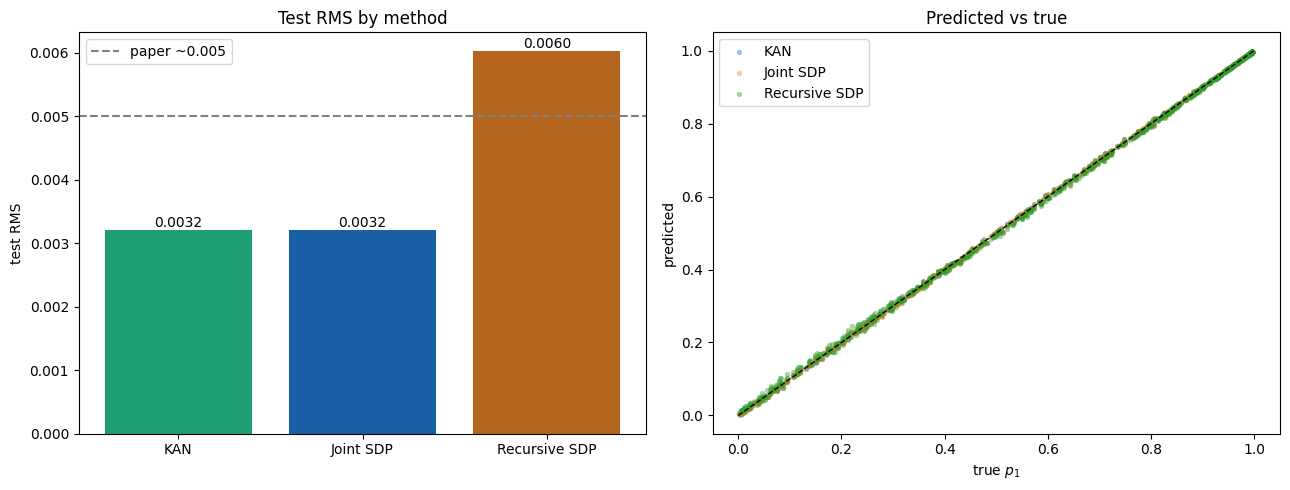

In [15]:
print("="*52)
print("  MOESM4  —  identical held-out test set (n=%d)" % len(Xte))
print("="*52)
print("  KAN            test RMS : %.5f" % rms_kan)
print("  Joint SDP      test RMS : %.5f" % rms_joint)
print("  Recursive SDP  test RMS : %.5f" % rms_rec)
print("  paper reported          : ~0.005 region")
print("="*52)

fig, ax = plt.subplots(1, 2, figsize=(13,5))
labels = ["KAN", "Joint SDP", "Recursive SDP"]; vals = [rms_kan, rms_joint, rms_rec]
ax[0].bar(labels, vals, color=["#1D9E75","#185FA5","#B5651D"])
ax[0].axhline(0.005, ls="--", c="grey", label="paper ~0.005"); ax[0].legend()
for i,v in enumerate(vals): ax[0].text(i, v, "%.4f"%v, ha="center", va="bottom")
ax[0].set_ylabel("test RMS"); ax[0].set_title("Test RMS by method")
ax[1].scatter(yte, p_te_kan, s=8, alpha=.35, label="KAN")
ax[1].scatter(yte, born_predict(Pi_joint, Xte), s=8, alpha=.35, label="Joint SDP")
ax[1].scatter(yte, born_predict(Pi_rec, Xte),  s=8, alpha=.35, label="Recursive SDP")
ax[1].plot([0,1],[0,1],"k--",lw=1); ax[1].legend()
ax[1].set_xlabel("true $p_1$"); ax[1].set_ylabel("predicted"); ax[1].set_title("Predicted vs true")
plt.tight_layout(); plt.show()

### 4.2 · Do the two SDP matrices agree? (fidelity)

The KAN has no matrix, so this check is SDP-vs-SDP only. Fidelity near 1.0 means joint and
recursive recovered the *same physical POVM* by two different routes — the strongest possible
internal consistency check.

$$F(A,B)=\frac{\left(\mathrm{Tr}\sqrt{\sqrt{A}\,B\,\sqrt{A}}\right)^2}{\mathrm{Tr}(A)\,\mathrm{Tr}(B)}$$

In [16]:
def fidelity(A, B):
    sA = sqrtm(A); M = sA @ B @ sA
    return float((np.real(np.trace(sqrtm(M)))**2) / (np.trace(A).real * np.trace(B).real))

print("Fidelity(Joint, Recursive) = %.4f" % fidelity(Pi_joint, Pi_rec))
print("(paper reports reconstruction fidelities > 98%)")

Fidelity(Joint, Recursive) = 0.9999
(paper reports reconstruction fidelities > 98%)


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1647105139.py:2: RuntimeWarning: divide by zero encountered in matmul
  sA = sqrtm(A); M = sA @ B @ sA
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1647105139.py:2: RuntimeWarning: overflow encountered in matmul
  sA = sqrtm(A); M = sA @ B @ sA
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_47492/1647105139.py:2: RuntimeWarning: invalid value encountered in matmul
  sA = sqrtm(A); M = sA @ B @ sA


### 4.3 · Physics check — the Fig. 2b structure

- **Rising diagonal** = number sensitivity (particle nature).
- **Negative leading off-diagonal, decaying with $j$** = phase sensitivity / coherence (wave nature).

Both SDP matrices should show this. The KAN can't be shown here — it has no matrix — which is
exactly *why* its value is the symbolic formula (next notebook), not a matrix to inspect.

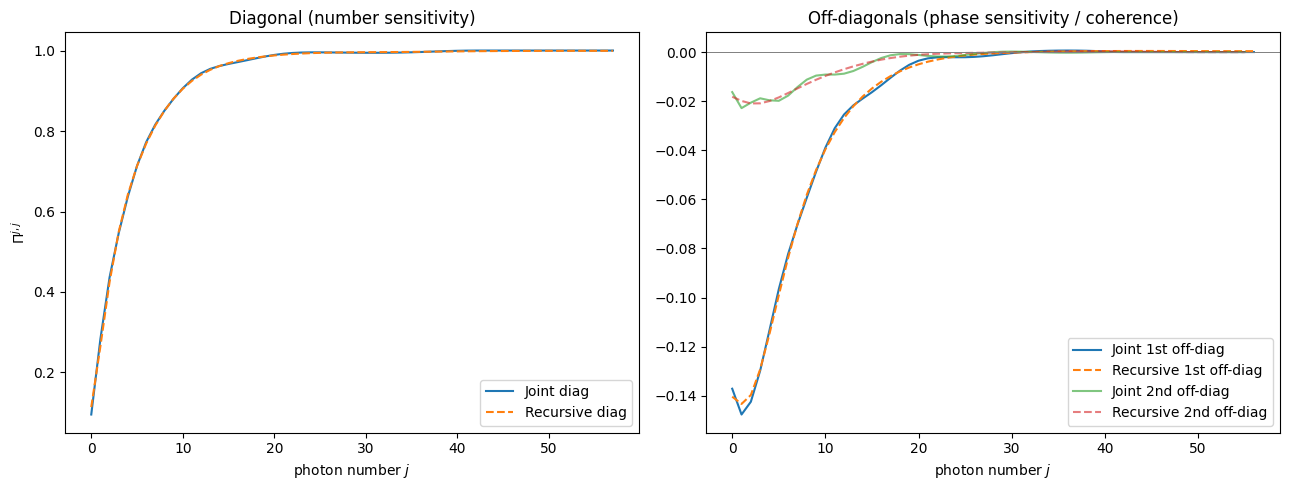

In [17]:
def diag_off(P):
    return np.real(np.diag(P)), np.real(np.diag(P,1)), np.real(np.diag(P,2))

dJ,o1J,o2J = diag_off(Pi_joint)
dR,o1R,o2R = diag_off(Pi_rec)
fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].plot(dJ, label="Joint diag"); ax[0].plot(dR, "--", label="Recursive diag")
ax[0].set_title("Diagonal (number sensitivity)"); ax[0].set_xlabel("photon number $j$"); ax[0].set_ylabel(r"$\Pi^{j,j}$"); ax[0].legend()
ax[1].plot(o1J, label="Joint 1st off-diag"); ax[1].plot(o1R, "--", label="Recursive 1st off-diag")
ax[1].plot(o2J, label="Joint 2nd off-diag", alpha=.6); ax[1].plot(o2R, "--", label="Recursive 2nd off-diag", alpha=.6)
ax[1].axhline(0, c="grey", lw=.7)
ax[1].set_title("Off-diagonals (phase sensitivity / coherence)"); ax[1].set_xlabel("photon number $j$"); ax[1].legend()
plt.tight_layout(); plt.show()

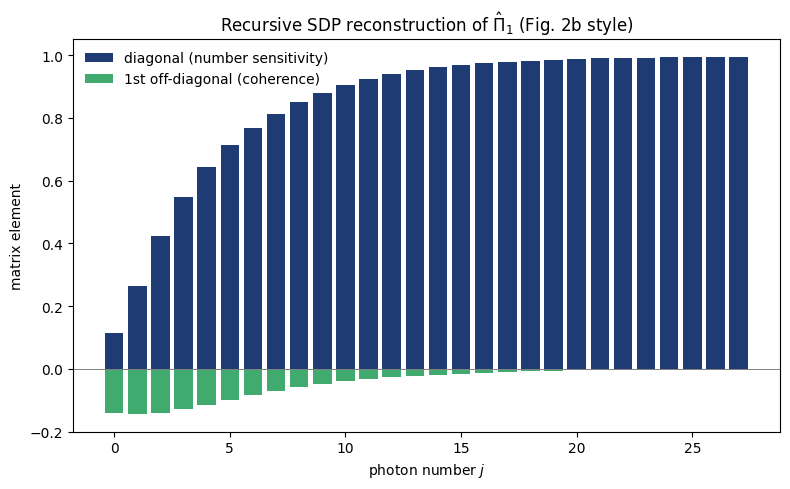

In [23]:
import numpy as np, matplotlib.pyplot as plt

show = 28
j = np.arange(show)
diag = np.real(np.diag(Pi_rec))[:show]      # diagonal: number sensitivity
off1 = np.real(np.diag(Pi_rec, 1))[:show-1] # 1st off-diagonal: coherence

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(j,      diag, color='#1f3b73', label='diagonal (number sensitivity)')
ax.bar(j[:-1], off1, color='#2ca25f', alpha=.9, label='1st off-diagonal (coherence)')
ax.axhline(0, color='grey', lw=.7)
ax.set_title(r'Recursive SDP reconstruction of $\hat\Pi_1$ (Fig. 2b style)')
ax.set_xlabel('photon number $j$')
ax.set_ylabel('matrix element')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 5 · Reading the results

**The level playing field (RMS).** All three predict click probability on the same 744 test rows.
- **Joint SDP** typically lands best (~0.003, paper's region) — it uses the full 2-D statistics under
  one PSD constraint.
- **Recursive SDP** (~0.006) reproduces the paper's literal algorithm and yields a valid POVM. It is
  slightly less precise here because phase-averaging compresses information, but its advantage is
  **scalability** — it is the only method that runs at $d=450$. (This accuracy ↔ tractability
  trade-off is the key methodological point. On a small APD, joint wins on accuracy; on the big PNRD,
  recursion is the only option.)
- **KAN** (~0.003) matches the joint SDP **with no physics** — no positivity, no Born rule, no
  operator, just two inputs.

**Internal consistency.** Joint and recursive matrices agree to fidelity ≈ 1.0 → they recovered the
*same physical POVM* two different ways. Strong cross-check.

**The physics.** Both matrices show the rising diagonal (number sensitivity) and the negative,
decaying leading off-diagonal (coherence) — the Fig. 2b signature, confirming the detector bridges
the wave–particle gap.

**What this tells us about the KAN's role.** A low KAN RMS is *necessary but not sufficient* to be
interesting — any flexible regressor can fit a smooth 2-D surface. The KAN earns its place only when
we extract its **symbolic formula** (`model.auto_symbolic()`) and ask whether that closed form exposes
the physics — the $e^{-|\alpha|^2}$ envelope, the $\cos\theta$ phase term — that the SDP gives only as
opaque numbers. That is the next step, and the actual meaning of *KAN-assisted* tomography.

### Notes for the thesis
- The recursive method's reduced functions MUST use a real phase integral (trapezoid), not a plain
  mean — the MOESM4 phase grid is offset, and a plain mean injects a constant imaginary artifact that
  ruins the small high-$l$ bands. Report this as a methodological finding.
- The recursive method is more sensitive to phase-reference calibration than the joint method
  (it phase-averages; joint never does). Worth a sentence.
- Truncation $D=58$, bands $L=4$, regulariser $\gamma=0.5$ as in the paper.